# Bagging: Meta Estimador

### ¿Qué es el Bagging?

* Imagina que le preguntas la misma pregunta a muchos expertos que han estudiado en grupos diferentes del mismo material. Cada grupo (modelo) ha visto partes distintas del material (datos), y su respuesta combinada suele ser más confiable que la de un solo experto.
* Bagging (acrónimo de *Bootstrap Aggregating*) es una técnica de `ensemble learning` utilizada en Machine Learning para mejorar la estabilidad, precisión y reducir el sobreajuste (overfitting) de los modelos de aprendizaje.
* ¿Cómo funciona Bagging?
  - **Bootstrap (muestreo con reemplazo)**: Se generan varios subconjuntos de datos de entrenamiento seleccionados aleatoriamente con reemplazo a partir del conjunto original. Cada subconjunto tiene el mismo tamaño que el conjunto original, pero algunas observaciones pueden repetirse y otras quedar fuera.
  - **Entrenamiento de modelos base**: Se entrena un modelo independiente (`base learner`) en cada subconjunto de datos. Normalmente se usan modelos con alta varianza como `árboles de decisión`.
  - **Agregación (Aggregating)**: Para tareas de clasificación, se combinan los resultados mediante votación mayoritaria. Para tareas de regresión, se promedian las predicciones.

* Ventajas del Bagging
  - Reduce la varianza: promediar varios modelos evita que los errores individuales dominen.
  - Disminuye el riesgo de sobreajuste: especialmente en modelos inestables como los árboles profundos.
  - Fácil de paralelizar: cada modelo se entrena de forma independiente.
    
* Ejemplos de algoritmos que usan Bagging
  - `Random Forest`: usa Bagging sobre árboles de decisión, añadiendo además selección aleatoria de variables en cada división.

### ¿Cuál es la diferencia entre Bagging, train_test_split, los sampleos y la técnica de validación cruzada?

* Aunque todas estas técnicas implican dividir o muestrear datos, tienen propósitos y contextos distintos.
1. Bagging (Bootstrap Aggregating)
   - Propósito: mejorar el rendimiento y estabilidad de un modelo reduciendo la varianza.
   - Toma múltiples muestras aleatorias con reemplazo del conjunto de entrenamiento (cada muestra tiene el mismo tamaño que el conjunto original, pero algunas observaciones se repiten y otras quedan fuera).
   - Entrena un modelo independiente en cada muestra.
   - Combina las predicciones (votación para clasificación, promedio para regresión).
   - ***los datos originales no se dividen en entrenamiento y prueba aquí; Bagging se aplica sobre el conjunto de entrenamiento ya definido.***
2. `train_test_split` (División Entrenamiento/Prueba)
   - Divide los datos en dos subconjuntos: entrenamiento (p.ej. 70–80%) y prueba (p.ej. 20–30%).
   - El modelo se entrena en el conjunto de entrenamiento y se evalúa en el de prueba.
   - los datos se dividen una sola vez, por lo que el resultado puede depender de cómo se hizo la división (puede ser inestable si el dataset es pequeño).
3. Sampleo o muestreo en general
   - Propósito: seleccionar subconjuntos de datos para algún objetivo específico.
   - Aleatorio simple: sin reemplazo (tomas una muestra única). Con reemplazo (bootstrap): como en Bagging.Estratificado: respetando la proporción de clases.
   - se usa en diferentes fases, tanto para crear conjuntos de entrenamiento, reducir tamaño de dataset, o balancear clases.
   - el muestreo es más una técnica general, Bagging y validación cruzada son casos específicos de muestreo.
5. Validación cruzada (Cross-Validation, CV)
   - Propósito: evaluar de manera más robusta y confiable el rendimiento de un modelo.
   - Divide los datos en k partes (folds).
   - Entrena el modelo k veces, cada vez usando k-1 folds para entrenar y 1 fold diferente para validar.
   - Promedia las métricas de cada fold.
   - Contexto: evaluación de modelos, selección de hiperparámetros (usado con GridSearchCV/RandomizedSearchCV).
   - todos los datos participan como entrenamiento y validación en diferentes iteraciones; reduce el riesgo de que la evaluación dependa de una sola partición.

* Analogía rápida:
  - `train_test_split`: Tomas un examen una sola vez para evaluar al alumno.
  - `cross-validation`: Tomas varios exámenes de diferentes temas y promedias su calificación (más confiable).
  - `bagging`: Tomas muchos grupos de estudiantes, cada grupo estudia diferentes partes del material, luego votan juntos.
  - `sampleo`: Técnica genérica de seleccionar subconjuntos para distintos propósitos.

* ***No siempre se aplican las cuatro técnicas, y no son pasos obligatorios en un pipeline fijo, sino herramientas que se usan en diferentes momentos y con diferentes propósitos.***

* Separación de datos de manera segura
  - Definir un conjunto de entrenamiento y prueba:
    - O bien `train_test_split` (p. ej. 80/20, estratificado si hay clases desbalanceadas).
    - O mejor aún validación cruzada (k-fold) para una evaluación más robusta.
* Selección y entrenamiento de modelos base
  - Probar modelos base (baseline) primero:
    - Ejemplo: regresión logística, árbol simple, dummy classifier (para tener referencia mínima).
    - Entrenar modelos candidatos (árboles, RandomForest, XGBoost, redes neuronales, etc.).
    - Usar validación cruzada para evaluar su rendimiento.

* Evaluación con métricas adecuadas
    - Verificar si el modelo está sobreajustado (comparar score en train vs validación/test).

* Optimización de hiperparámetros
    - Usar GridSearchCV, RandomizedSearchCV o Bayesian Optimization.
    - Mantener validación cruzada para evaluar cada conjunto de hiperparámetros.
    - Si un modelo no es suficiente: Bagging (RandomForest) o Boosting (XGBoost, LightGBM) para reducir varianza y mejorar performance.

### Clasificación y Regresión: Datos salariales

* Este dataset será usado tanto para predir si un salario es alto o bajo para modelos de clasificación.
* Igualmente tenemos una columna objetivo para los modelos de regresión.

In [4]:
import pandas as pd

personas = pd.read_csv("salarios.csv")
personas.head(7)

,edad,estudio,horas,clase_salario,valor_salario
0,27,9,40,0,12967.330
1,30,9,40,0,20171.400
2,42,9,40,1,39051.040
3,68,9,25,1,33567.250
4,34,8,40,0,8247.420
5,26,13,50,0,6769.345
6,23,4,25,0,2266.799


### N Muestreos para N Modelos

* Sacamos 5 muestras de 10% totales de los datos, en este caso tocarán muestras de 10 datos.

In [6]:
for i in range(5):
    print("="*5, f'Muestra {i}', "="*5)
    print(personas.sample(frac=1/10), "\n")

===== Muestra 0 =====
    edad  estudio  horas  clase_salario  valor_salario
36    44       16     50              0       24655.32
13    58        9     40              1       26133.39
47    35       10     60              0        9017.51
77    19        5     40              0        2285.43
27    21       10     25              0       22140.10
82    49        9     40              0       19426.15
57    62       13      1              0        3230.65
84    66        7     40              1       32095.39
38    47        9     40              0       17935.66
28    30        9     60              0        5291.26 

===== Muestra 1 =====
    edad  estudio  horas  clase_salario  valor_salario
44    36       14     60              0       15724.75
20    58        4     40              1       26133.39
91    20        9     40              0        2285.43
73    50       14     45              1       26139.60
94    37        5     50              1       40305.55
55    30       10  

### Escalamiento de los Datos

In [22]:
from sklearn.preprocessing import MinMaxScaler

### EScalamos todos los datos
personas = MinMaxScaler().fit_transform(personas)
print("Dimensión: ", personas.shape)
print("\t edad \testudio \thoras \tclase_salario \tvalor_salario")
personas[0:5]

Dimensión:  (100, 5)
	 edad 	estudio 	horas 	clase_salario 	valor_salario


array([[0.15873016, 0.53333333, 0.54929577, 0.        , 0.2510676 ],
       [0.20634921, 0.53333333, 0.54929577, 0.        , 0.39675954],
       [0.3968254 , 0.53333333, 0.54929577, 1.        , 0.77857306],
       [0.80952381, 0.53333333, 0.33802817, 1.        , 0.66767131],
       [0.26984127, 0.46666667, 0.54929577, 0.        , 0.15561422]])

### Visualización de los Datos: Estudio, Horas, Edad -> Salario

* El motivo de usar la transpuesta (.T) en ese código está relacionado con cómo están organizados los datos en el arreglo de NumPy y cómo queremos acceder a ellos.
* Después de escalar con MinMaxScaler, personas es un array 2D de forma (n_muestras, n_features).
  - Cada fila representa un individuo.
  - Cada columna representa una característica: edad, estudio, horas, clase_salario, valor_salario.
* `personas[:, 0]` → todas las edades.
* `personas[:, 1]` → todos los años de estudio.
* `personas[:, 3]` → todas las clases de salario.
* Para no hacer eso directamente sacamos `personas.T[0]` → columna 0 original (edades) pero ahora como un array de 100 elementos.
* Se define una tupla con dos colores: uno para la `clase 0` y otro para la `clase 1`.
* Se recorre cada clase de la variable objetivo: primero 0, luego 1.
* `personas.T[0][personas.T[3]==clase]` → selecciona únicamente las edades de las personas que pertenecen a la clase actual.

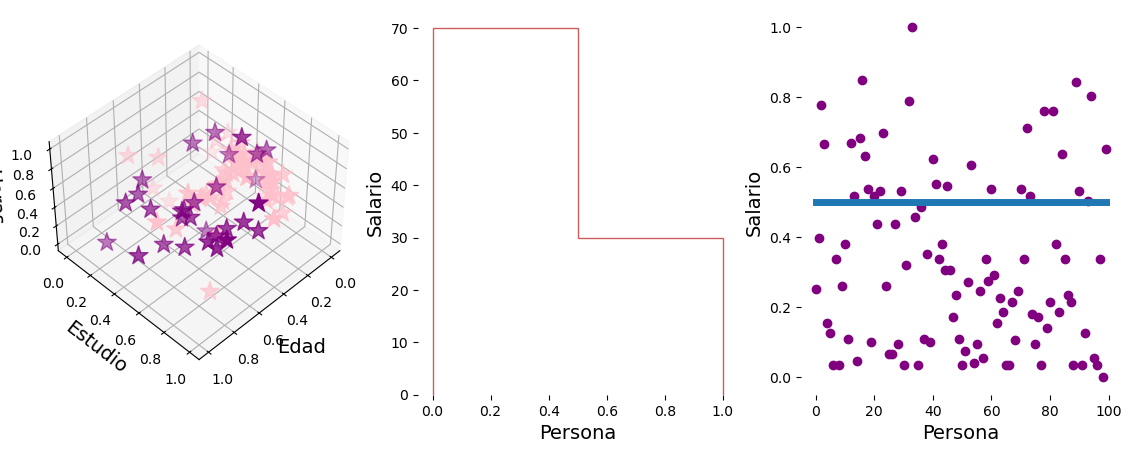

In [20]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 5))

# Gráfica de dispersión -> Edad, Estudio y Horas

### Grafica 3D
ax = fig.add_subplot(1, 3, 1, projection="3d")
colores = ("pink", "purple")

### Se recorre 2 veces por las 2 clases.
for clase in (0, 1):
    ax.scatter(personas.T[0][personas.T[3]==clase], 
               personas.T[1][personas.T[3]==clase], 
               personas.T[2][personas.T[3]==clase],
               marker="*", c=colores[clase], s=200)
### Ponemos nombre a las dimensiones
ax.set_xlabel("Edad", size=14)
ax.set_ylabel("Estudio", size=14)
ax.set_zlabel("Horas", size=14)
ax.view_init(45, 45)

# Histograma -> clase salarial
ax = fig.add_subplot(1, 3, 2)
### Graficamos la clasificación de salario alto y bajo
ax.hist(personas.T[3], bins=2, histtype="step", color="indianred")
ax.set_ylabel("Salario", size=14)
ax.set_xlabel("Persona", size=14)
plt.setp(ax.spines.values(), linewidth=0)

# Visualización del salario de las personas
ax = fig.add_subplot(1, 3, 3)
### Graficamos el salario monetario por persona.
ax.plot(personas.T[4], marker="o", linewidth=0, color="purple")

### Graficamos una linea intermedia para poder "Clasificar si es alto o bajo"
ax.plot([0.5]*100, linewidth=5)
ax.set_ylabel("Salario", size=14)
ax.set_xlabel("Persona", size=14)
plt.setp(ax.spines.values(), linewidth=0)
plt.show()

### Creación de Meta-modelos Bagging: Estimador base: K-vecinos más cercanos KNN

* Nosotros usaremos para este ejemplo los 2 KNN como modelos.

In [25]:
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import BaggingRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import r2_score

# Separando las características de las variables objetivo
### Extramos los datos correspondientes.
datos = personas.T[:-2].T ### Todos los datos sin las 2 clases objetivo.
clase = personas.T[3] ### Saldo Clasificado
valor = personas.T[4] ### Saldo Monetario

# Instanciamos nuestros KNN base.
clasificador = KNeighborsClassifier(n_neighbors=3)
regresor = KNeighborsRegressor(n_neighbors=3)

n = 50 ### números de modelos

# Modelos bagging para clasificaión y regresión con 30% de muestra
meta_clasificador = BaggingClassifier(estimator=clasificador, 
                                      n_estimators=n, 
                                      max_samples=0.30).fit(datos, clase)

meta_regresor = BaggingRegressor(estimator=regresor, 
                                 n_estimators=n, 
                                 max_samples=0.30).fit(datos, valor)

# Métricas relevantes para clasificación y determinación
print("Accuracy:", 
      accuracy_score(clase, meta_clasificador.predict(datos)))
print("Coeficiente de determinación:", 
      r2_score(valor, meta_regresor.predict(datos)))

Accuracy: 0.82
Coeficiente de determinación: 0.3104502179556251
